In [23]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import tifffile as tf
from glob import glob
import os

from scipy import ndimage

In [24]:
struc1 = ndimage.generate_binary_structure(2,1)
struc2 = ndimage.generate_binary_structure(2,2)

wsrc = '../cell_dams/'
nsrc = '../nuclear_mask/'
csrc = '../data/'
dst = '../results/'

sample = 'A2'

In [25]:
transcriptomes = sorted([foo.split('/')[-2] for foo in glob(csrc + sample + '_data/*/')])
tidx = 0
filename = csrc + sample + '_data/' + transcriptomes[tidx] + '/' + transcriptomes[tidx] + ' - localization results by cell.csv'
print(filename)
df = pd.read_csv(filename)
print(df.shape)
df = df.iloc[~np.any(df.iloc[:, :5].isnull().values, axis=1)]
df = df[df['Cell.Area..px.'] > 9]
print(df.shape)

sel = [0,3,4,5,6,7,8,9]
df = df.astype(dict(zip(df.columns[np.array(sel)], [int for i in range(len(sel))])))

dcoords = np.round(df.iloc[:, 1:3].values).astype(int).T

df.head()

../data/A2_data/BAC45727/BAC45727 - localization results by cell.csv
(1219, 24)
(1210, 24)


,Cell.ID..,X.location,Y.location,Bouding.box.X,Bouding.box.Y,Bouding.box.width,Bouding.box.height,Cell.Area..px.,Nucleus.Area..px.,Total.transcript..,...,Median.distance.from.nucleus.incl..nucleus..px.,Median.distance.from.nucleus.excl..nucleus..px.,X1st.quartile.distance.w..nucleus..px.,X1st.quartile.distance.w.o.nucleus..px.,X3rd.quartile.distance.w..nucleus..px.,X3rd.quartile.distance.w.o.nucleus..px.,nuclear.only.transcripts,average.nuclear.transcript.percentage,Total.cells.expressed,Nuc_cells_exp
1,1,3497.386,7809.510,0,0,10720,15008,73876821,297715,11,...,88.0,88.0,39.0,39.0,363.0,363.0,0.0,0.0,20,9
2,2,8538.528,763.141,8360,567,349,403,86985,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,20,9
3,3,9386.261,1371.121,8423,745,1838,1448,1291543,4669,1,...,36.0,36.0,0.0,0.0,36.0,36.0,0.0,0.0,20,9
4,4,6978.262,978.997,6829,822,268,373,51419,173,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,20,9
5,5,8162.576,1460.196,7730,851,785,1505,647899,648,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,20,9


In [27]:
wall = tf.imread(wsrc + sample + '_dams.tif')[0]
filename = wsrc + sample + '_aux_dams.tif'
if not os.path.isfile(filename):
    wall[dcoords[1], dcoords[0]] = 1
    tf.imwrite(filename, wall, photometric='minisblack')
    print('Written',filename)

wall = wall.astype(bool)
print('Walls:', wall.shape, wall.dtype, wall.min(), wall.max(), '\n', sep='\t')

Walls:	(3001, 2144)	bool	False	True	



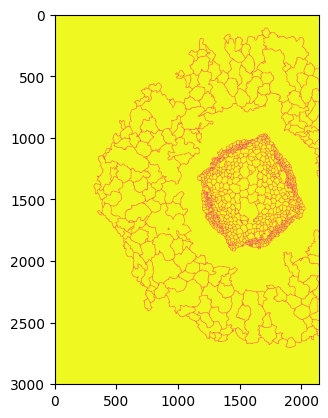

In [28]:
plt.imshow(wall, cmap='plasma')

In [33]:
print(wall.shape[0]/wall.shape[1])
print(edt.shape[0]/edt.shape[1])

1.3997201492537314
1.4


In [29]:
edt = tf.imread(nsrc + sample + '_EDT.tif')
print('Nuclei:', edt.shape, edt.dtype, edt.min(), edt.max(), '\n', sep='\t')

wcoords = np.array(np.nonzero(~wall))
print('Walls', wcoords.shape, '\n')

nuclei = edt < 2
print('Nuclei:', nuclei.shape, nuclei.dtype, nuclei.min(), nuclei.max(), '\n', sep='\t')

ncoords = np.array(np.nonzero(nuclei))
print('Nuclei', ncoords.shape)

Nuclei:	(15008, 10720)	float32	0.0	4185.1177	

Walls (2, 171840) 

Nuclei:	(15008, 10720)	bool	False	True	

Nuclei (2, 1278804)


In [30]:
label, num = ndimage.label(wall, struc1)
hist, bins = np.histogram(label, bins=range(1,num+2))
cnuclei = np.asarray(ndimage.center_of_mass(wall, label, range(1,num+1)))
print('Detected',num,'cells')

Detected 1257 cells


In [15]:
ratio = np.zeros(dcoords.shape[1])

for j in range(len(ratio)):
    lab = label[dcoords[1,j], dcoords[0,j]] 
    foo = np.array([df.iloc[j,7], hist[lab-1]])
    ratio[j] = np.divide(*np.sort(foo))

IndexError: index 7810 is out of bounds for axis 0 with size 3430

In [8]:
diff = np.zeros(dcoords.shape[1])

for j in range(len(ratio)):
    lab = label[dcoords[1,j], dcoords[0,j]]
    foo = (cnuclei[lab-1, 1] - df.iloc[j,1])**2 + (cnuclei[lab-1, 0] - df.iloc[j,2])**2
    diff[j] = np.sqrt(foo)
dq25, dq75 = np.quantile(diff, [0.25, 0.75])
diqr = dq75 - dq25

diffcpy = diff.copy()
diffcpy[diff > dq75 + 3*diqr ] = dq75 + 3*diqr

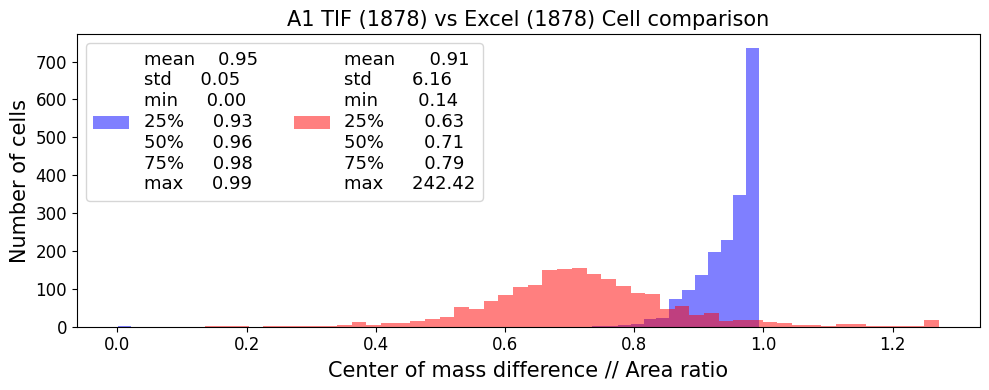

In [9]:
fs = 15

fig, ax = plt.subplots(1,1,figsize=(10,4), sharex=True, sharey=True)
ax = np.atleast_1d(ax).ravel()

_,_,h1 = ax[0].hist(ratio, bins=50, color='b', alpha=0.5);
ax[0].set_xlabel('Center of mass difference // Area ratio', fontsize=fs)
ax[0].set_ylabel('Number of cells', fontsize=fs)
_, _,h2 = ax[0].hist(diffcpy, bins=50, color='r', alpha=0.5)

ax[0].tick_params(labelsize=fs-3)

ax[0].legend([h1, h2], 
             [pd.Series(foo).describe().drop('count').round(2).to_string() for foo in [ratio, diff] ],
             ncols = 2, loc='upper left', fontsize=fs-2)


title = sample + ' TIF ({}) vs Excel ({}) Cell comparison'.format(num, dcoords.shape[1])
ax[0].set_title(title, fontsize=fs);

fig.tight_layout()
filename = dst + sample + '_cell_tif_excel_comparison'
plt.savefig(filename + '.png', format='png', dpi=150, bbox_inches='tight', pil_kwargs={'optimize':True})

In [10]:
np.nonzero(diff > 5)

(array([  0, 276]),)

In [11]:
j = 17
w = 50

highlight = wall.copy().astype(np.uint8)
lab = label[dcoords[1,j], dcoords[0,j]] 
highlight[label == lab] = 2

mean = df.iloc[j, 1:3].values
foo = df.iloc[j, 3:7].values.astype(int)
ss = np.s_[foo[1]-w:foo[1]+foo[3]+w, foo[0]-w:foo[0]+foo[2]+w]
box = np.array([
                [foo[0], foo[0]+foo[2], foo[0]+foo[2], foo[0], foo[0]],
                [foo[1], foo[1], foo[1]+foo[3], foo[1]+foo[3], foo[1]]
               ])
box[0] -= ss[1].start
box[1] -= ss[0].start
print(diff[j])
print(ratio[j])

0.748776900776377
0.9818433591152168


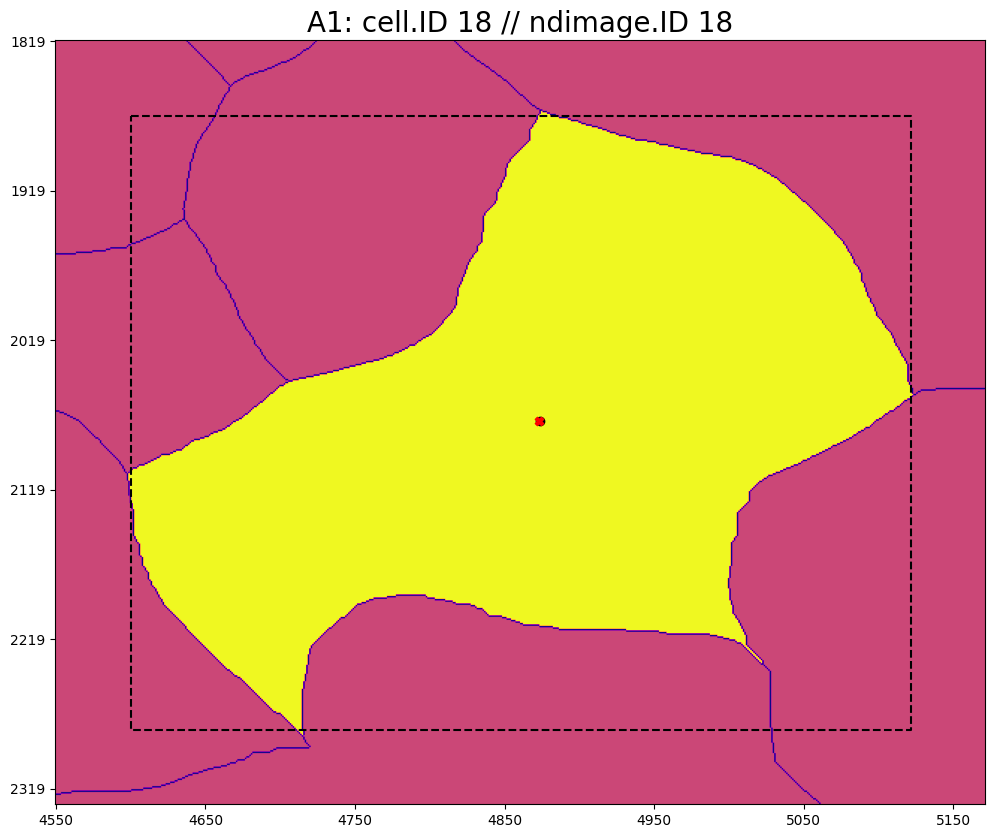

In [12]:
fig, ax = plt.subplots(1,1,figsize=(12,12))

ax.imshow(highlight[ss], cmap='plasma');
ax.scatter([mean[0] - ss[1].start], [mean[1] - ss[0].start], c='k');
ax.scatter([cnuclei[lab-1, 1] - ss[1].start], [cnuclei[lab-1, 0] - ss[0].start], c='r', marker='X');
ax.plot(box[0], box[1], ls='--', c='k')

step = int(np.ediff1d(ax.get_xticks())[0])
ax.set_xticks(np.arange(0, foo[2] + 2*w, step), np.arange(ss[1].start, ss[1].stop, step))
ax.set_yticks(np.arange(0, foo[3] + 2*w, step), np.arange(ss[0].start, ss[0].stop, step))

ax.margins(0)
title = sample + ': cell.ID {} // ndimage.ID {}'.format(df.iloc[j,0], lab)
ax.set_title(title, fontsize=20);

filename = dst + sample + '_cell_ID_{:04d}'.format(df.iloc[j,0])
plt.savefig(filename+'.png', format='png', dpi=150, bbox_inches='tight', pil_kwargs={'optimize':True})

In [13]:
np.array(list(set(bins[:-1]) - set(label[dcoords[1], dcoords[0]])))

array([  1, 276])

In [14]:
uniq, counts = np.unique(label[dcoords[1], dcoords[0]], return_counts=True)
highlight = wall.copy().astype(np.uint8)
for bar in uniq[np.nonzero(counts > 1)[0]]:
    highlight[label == bar] = 2

multip = []
for bar in uniq[np.nonzero(counts > 1)[0]]:
    multip.append(np.nonzero(label[dcoords[1], dcoords[0]] == bar)[0])
    print(bar, multip[-1])

860 [  0 858]
1166 [ 276 1165]


In [15]:
j = 1
df.iloc[multip[j]]

,Cell.ID..,X.location,Y.location,Bouding.box.X,Bouding.box.Y,Bouding.box.width,Bouding.box.height,Cell.Area..px.,Nucleus.Area..px.,Total.transcript..,...,Median.distance.from.nucleus.incl..nucleus..px.,Median.distance.from.nucleus.excl..nucleus..px.,X1st.quartile.distance.w..nucleus..px.,X1st.quartile.distance.w.o.nucleus..px.,X3rd.quartile.distance.w..nucleus..px.,X3rd.quartile.distance.w.o.nucleus..px.,nuclear.only.transcripts,average.nuclear.transcript.percentage,Total.cells.expressed,Nuc_cells_exp
278,278,7332.835,7920.706,4345,5053,6301,5562,11270791,160180,1,...,4.0,4.0,0.0,0.0,4.0,4.0,0.0,0.0,34,5
1170,1170,7104.776,8001.955,6854,7803,512,385,134570,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,34,5


In [16]:
w = 4500
mean = np.mean(df.iloc[multip[j], 1:3].values, axis=0).astype(int)
ss = np.s_[mean[1] - w: mean[1] + w, mean[0] - w:mean[0] + w]
ss

(slice(3461, 12461, None), slice(2718, 11718, None))

In [17]:
foo = df.iloc[multip[j], 3:7].values
boxes = [np.zeros((2,5)) for i in range(len(foo))]

for i in range(len(foo)):
    boxes[i][0] = [foo[i,0], foo[i,0]+foo[i,2], foo[i,0]+foo[i,2], foo[i,0], foo[i,0]]
    boxes[i][1] = [foo[i,1], foo[i,1], foo[i,1]+foo[i,3], foo[i,1]+foo[i,3], foo[i,1]]
    
    boxes[i][0] -= ss[1].start
    boxes[i][1] -= ss[0].start
boxes

[array([[1627., 7928., 7928., 1627., 1627.],
        [1592., 1592., 7154., 7154., 1592.]]),
 array([[4136., 4648., 4648., 4136., 4136.],
        [4342., 4342., 4727., 4727., 4342.]])]

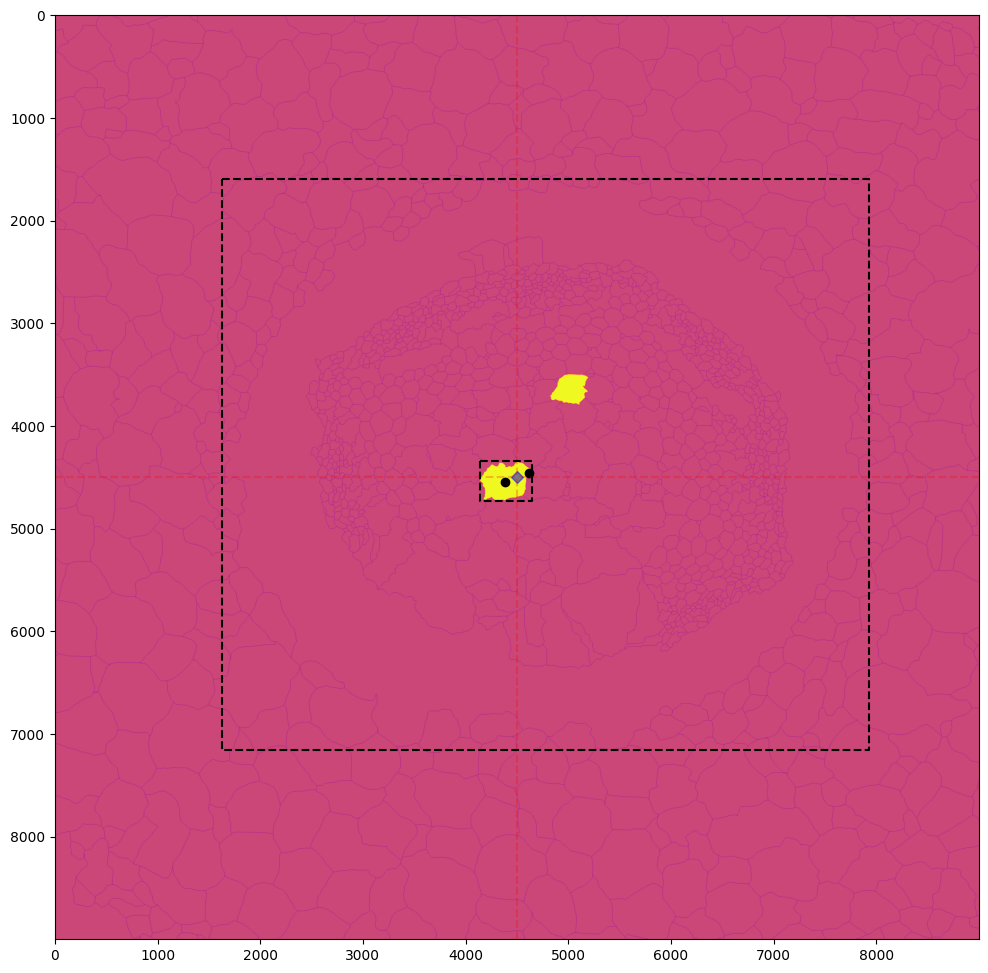

In [18]:
fig, ax = plt.subplots(1,1,figsize=(12,12))

ax.imshow(highlight[ss], cmap='plasma');
ax.scatter(dcoords[:, multip[j]][0] - ss[1].start, dcoords[:, multip[j]][1] - ss[0].start, c='k')
ax.scatter([mean[0] - ss[1].start], [mean[1] - ss[0].start], c='blue', marker='D', alpha=0.5)
ax.axvline(w, c='r', alpha=0.25, ls='--')
ax.axhline(w, c='r', alpha=0.25, ls='--')
for i in range(len(boxes)):
#for i in [1]:
    ax.plot(boxes[i][0], boxes[i][1], ls='--', c='k')

ax.margins(0)

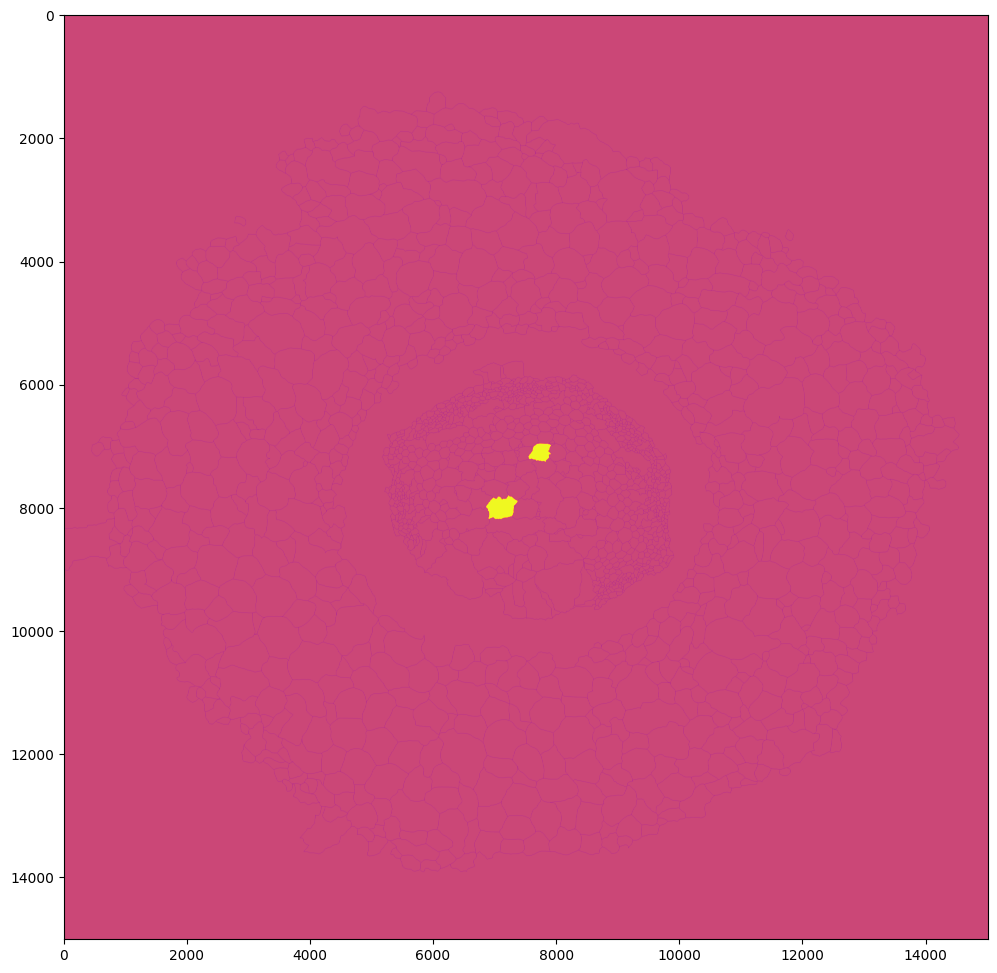

In [19]:
fig, ax = plt.subplots(1,1,figsize=(12,12))

ax.imshow(highlight, cmap='plasma');
#ax.scatter(dcoords[0], dcoords[1], c='gray', s=1, marker='.');
#ax.scatter(ncoords[1], ncoords[0], c='gray', s=0.0001, marker='.');
#ax.scatter(wcoords[1], wcoords[0], c='yellow', s=0.1, marker='.');

# Just look at transcript

In [45]:
filename = csrc + sample + '_data/32771-slide1_' + sample + '_results.txt'
data = pd.read_csv(filename, header=None, sep='\t')
data = data.drop(columns=[4])
data.columns = ['X', 'Y', 'Z', 'T']
print(len(transcriptomes))
print(data.shape)
data.head()

97
(180846, 4)


,X,Y,Z,T
0,4774,1294,22,BAC47856
1,4745,1264,22,GLYMA_02G003700
2,5362,203,20,BAC46169
3,5754,2088,25,BAC46169
4,6223,1722,28,GLYMA_06G090100


In [65]:
tidx = 17

tcoords = data.loc[ data['T'] == transcriptomes[tidx] , ['X', 'Y', 'Z'] ].values.T
print(transcriptomes[tidx], tcoords.shape)

GLYMA_02G149100 (3, 97)


In [66]:
mask = nuclei[ tcoords[1,:], tcoords[0,:] ]
print(np.sum(mask), len(mask) - np.sum(mask), np.round(100*(len(mask) - np.sum(mask))/len(mask),1), '%', sep='\t')

0	97	100.0	%


NameError: name 'tcoords' is not defined

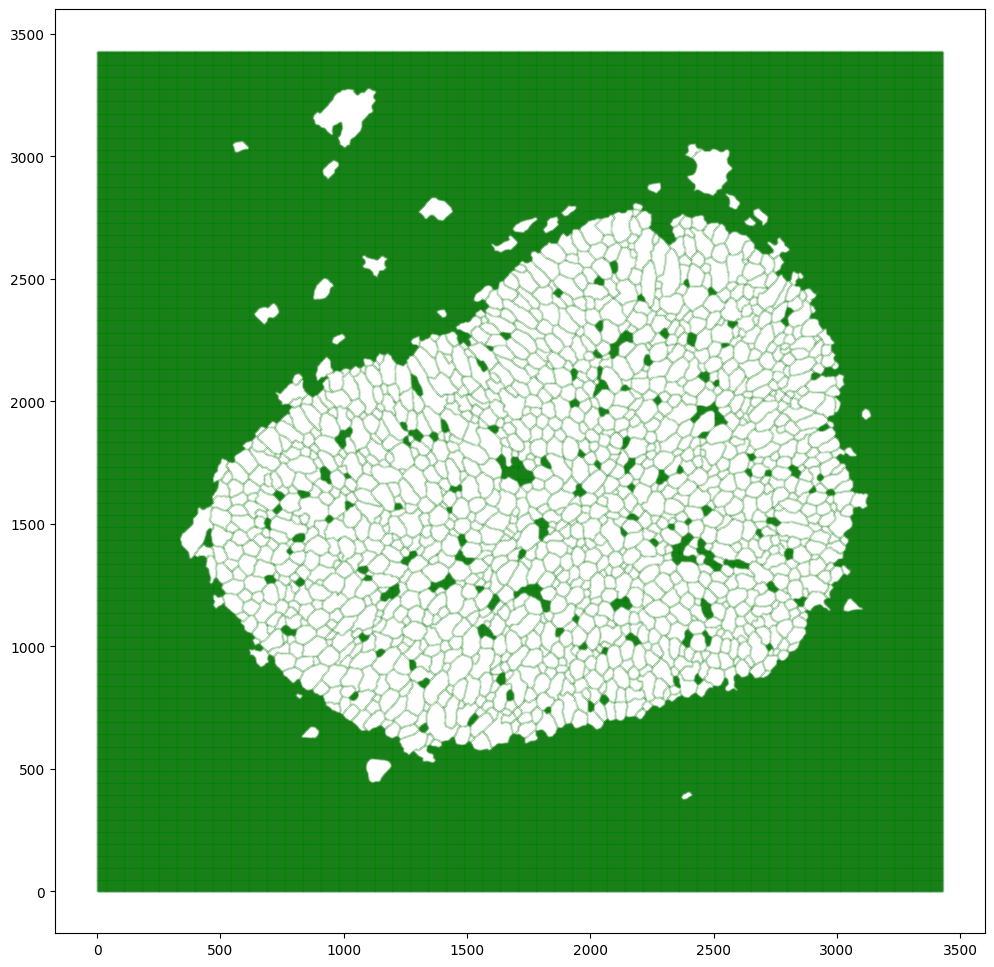

In [16]:
fig, ax = plt.subplots(1,1,figsize=(12,12))
ax.scatter(wcoords[1], wcoords[0], c='g', s=.1, marker='.', alpha=0.1, zorder=2);

ax.scatter(tcoords[0, ~mask], tcoords[1,~mask], c='magenta', s=1, marker='.', zorder=3);

ax.scatter(ncoords[1], ncoords[0], c='k', s=.1, marker='.', alpha=0.05, zorder=4);
ax.scatter(tcoords[0, mask], tcoords[1,mask], c='cyan', s=1, marker='.', zorder=5);

ax.set_aspect('equal')
ax.margins(0);

ax.set_title(sample + ': ' + transcriptomes[tidx], fontsize=fs);